# Experiment 2 (Improved) — VAE Data Augmentation

Improved Beta-VAE pipeline for the QUIDA fall-detection datasets, addressing the issues found in the
baseline run (posterior collapse, low diversity, distribution mismatch on the wide sensor sets).

**Changes vs baseline**
- **KL handling:** free-bits floor + β-annealing (ramp β from 0). Prevents posterior collapse and lifts diversity.
- **Preprocessing (`Prep`, reversible):** signed-log for the large radar magnitudes -> drop constant/dead
  feature columns -> optional PCA to a compact space so the wide datasets are learnable from few samples
  -> MinMax to `[0,1]`. Generation inverts all of it back to the original feature space.
- **Generation:** sample the latent from the *aggregated posterior* (fitted to the encoder outputs)
  instead of the N(0, I) prior.

Outputs go to `vae_generated_improved/` so they can be compared against the baseline `vae_generated/`.
Everything else (independent per-dataset experiments, metrics, visuals, saving) is unchanged.

## 1. Import libraries

In [27]:
from __future__ import annotations

import os, json, pickle, random, warnings, time
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import rbf_kernel
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import pdist

import tensorflow as tf
try:
    import keras
    from keras import layers
except ImportError:
    from tensorflow import keras
    from tensorflow.keras import layers

_saving = getattr(keras, "saving", None)
def _pick(fn):
    return getattr(_saving, fn, None) or getattr(keras.utils, fn, None)
register_keras_serializable = _pick("register_keras_serializable") or (lambda **k: (lambda c: c))
serialize_keras_object      = _pick("serialize_keras_object")
deserialize_keras_object    = _pick("deserialize_keras_object")

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda v: f"{v:,.5f}")

print("TensorFlow:", tf.__version__)
print("Keras     :", keras.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")


TensorFlow: 2.16.1
Keras     : 3.3.3
GPUs: none (CPU)


## 2. Configuration

In [44]:
@dataclass
class Config:
    # --- data ---
    data_dir: Path = field(default_factory=lambda: Path.cwd())
    output_dir: Path = field(default_factory=lambda: Path.cwd() / "vae_generated_improved")
    dataset_glob: str = "*_raw.npy"
    datasets: dict | None = None

    # --- reproducibility / split ---
    seed: int = 42
    val_split: float = 0.2

    # --- preprocessing (all reversible) ---
    use_signed_log: bool = True       # compress large-magnitude features (radar)
    drop_constant: bool = True        # remove dead / zero-variance columns
    const_eps: float = 1e-8
    use_pca: bool = True              # reduce wide feature spaces so few samples suffice
    pca_components: int = 32          # target modeled dim when PCA kicks in (auto-skipped if F is small)

    # --- model ---
    latent_dim: int = 16
    beta: float = 1.0                 # target KL weight (reached after annealing)
    free_bits: float = 0.5            # min nats per latent dim before KL is penalised (anti-collapse)
    kl_anneal_epochs: int = 30        # ramp beta 0 -> beta over this many epochs
    base_filters: int = 64

    # --- training ---
    epochs: int = 400
    batch_size: int = 32
    learning_rate: float = 1e-3
    early_stopping_patience: int = 40

    # --- generation ---
    n_synthetic: int | None = None    # <<< SET AN ABSOLUTE COUNT HERE (e.g. 1000) to generate that many samples
    synthetic_ratio: float = 10.0      # used only when n_synthetic is None -> n = ratio * n_real
    sample_from_posterior: bool = True

    # --- evaluation ---
    run_tsne: bool = True
    tsne_max_points: int = 500
    eval_subsample: int = 600

    # --- health thresholds ---
    kl_collapse_thresh: float = 1e-2
    overfit_ratio: float = 1.5

CFG = Config()
CFG.output_dir.mkdir(parents=True, exist_ok=True)
print("Data dir  :", CFG.data_dir)
print("Output dir:", CFG.output_dir)
print("Discovery :", CFG.dataset_glob if CFG.datasets is None else "explicit list")


Data dir  : c:\Users\mabideen\Downloads\Data_Augmentation\exp_2
Output dir: c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_generated_improved
Discovery : *_raw.npy


In [29]:
def set_seeds(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    try:
        keras.utils.set_random_seed(seed)
    except Exception:
        tf.random.set_seed(seed)

set_seeds(CFG.seed)


## 3. Automatically discover and load the four datasets

In [30]:
def _clean_name(filename: str) -> str:
    stem = Path(filename).stem
    return stem[:-4] if stem.endswith("_raw") else stem

def discover_datasets(cfg: Config) -> dict[str, np.ndarray]:
    if cfg.datasets:
        items = list(cfg.datasets.items())
        missing = [str(cfg.data_dir / f) for _, f in items if not (cfg.data_dir / f).exists()]
        if missing:
            raise FileNotFoundError("Missing dataset file(s):\n  " + "\n  ".join(missing))
    else:
        files = sorted(cfg.data_dir.glob(cfg.dataset_glob), key=lambda q: (q.name.count("_"), q.name))
        if not files:
            raise FileNotFoundError(f"No files matching {cfg.dataset_glob!r} in {cfg.data_dir}")
        items = [(_clean_name(q.name), q.name) for q in files]
    data = {}
    for name, fname in items:
        arr = np.load(cfg.data_dir / fname, allow_pickle=False).astype(np.float32)
        data[name] = arr
        print(f"  discovered {name:16s} <- {fname:26s} shape={arr.shape}")
    print(f"\n  {len(data)} independent dataset(s) - each trained separately, never merged.")
    return data

RAW = discover_datasets(CFG)


  discovered X_imu            <- X_imu_raw.npy              shape=(99, 32, 3)
  discovered X_imu_ir         <- X_imu_ir_raw.npy           shape=(99, 32, 771)
  discovered X_imu_radar      <- X_imu_radar_raw.npy        shape=(99, 32, 1137)
  discovered X_imu_ir_radar   <- X_imu_ir_radar_raw.npy     shape=(99, 32, 1905)

  4 independent dataset(s) - each trained separately, never merged.


## 4. Data validation

In [31]:
def load_metadata(cfg: Config, name: str):
    for cand in (f"{name}_meta.json", f"{name}.json", f"{name}_meta.csv"):
        q = cfg.data_dir / cand
        if q.exists():
            return json.loads(q.read_text()) if q.suffix == ".json" else pd.read_csv(q).to_dict("list")
    return None

def validate_dataset(name: str, X: np.ndarray, cfg: Config) -> np.ndarray:
    assert X.ndim == 3, f"{name}: expected 3-D (N, T, F), got {X.shape}"
    N, T, F = X.shape
    assert N > 0 and T > 0 and F > 0, f"{name}: empty axis in {X.shape}"
    n_nan, n_inf = int(np.isnan(X).sum()), int(np.isinf(X).sum())
    if n_nan or n_inf:
        print(f"  ! {name}: {n_nan} NaN / {n_inf} Inf -> imputing per-feature mean")
        X = np.where(np.isfinite(X), X, np.nan)
        feat_mean = np.nan_to_num(np.nanmean(X.reshape(-1, F), axis=0))
        inds = np.where(~np.isfinite(X)); X[inds] = np.take(feat_mean, inds[2])
    n_const = int((np.ptp(X.reshape(-1, F).astype(np.float64), axis=0) <= cfg.const_eps).sum())
    meta = load_metadata(cfg, name)
    meta_msg = f"metadata={list(meta)}" if meta else "metadata=none"
    print(f"  {name:16s} N={N:<5d} T={T:<4d} F={F:<5d} const_cols={n_const:<5d} "
          f"min={X.min():+.2f} max={X.max():+.2f} | {meta_msg}")
    return X.astype(np.float32)

RAW = {name: validate_dataset(name, X, CFG) for name, X in RAW.items()}


  X_imu            N=99    T=32   F=3     const_cols=0     min=-73.38 max=+72.09 | metadata=none
  X_imu_ir         N=99    T=32   F=771   const_cols=0     min=-73.38 max=+72.09 | metadata=none
  X_imu_radar      N=99    T=32   F=1137  const_cols=294   min=-73.38 max=+1522.99 | metadata=none
  X_imu_ir_radar   N=99    T=32   F=1905  const_cols=294   min=-73.38 max=+1522.99 | metadata=none


## 5. Reversible preprocessing (`Prep`) + train/val split

`Prep` is fit on **training data only** and encapsulates the full reversible chain: signed-log -> drop
constant columns -> optional PCA -> MinMax `[0,1]`. `transform` maps real data into the modeled space;
`inverse` maps generated data all the way back to the original feature space (re-inserting the dropped
constant columns). Each dataset gets its own `Prep`.

In [32]:
def _slog(x):  return np.sign(x) * np.log1p(np.abs(x))
def _islog(y): return np.sign(y) * np.expm1(np.abs(y))

class Prep:
    def __init__(self, cfg: Config): self.cfg = cfg
    def fit(self, X_tr):
        N, T, F = X_tr.shape; self.T, self.F_full = T, F
        orig = X_tr.reshape(-1, F).astype(np.float64)
        self.keep = (np.ptp(orig, axis=0) > self.cfg.const_eps) if self.cfg.drop_constant else np.ones(F, bool)
        logf = _slog(orig) if self.cfg.use_signed_log else orig
        self.const = logf.mean(0)                       # value (log space) to re-insert for dropped cols
        kept = logf[:, self.keep]
        if self.cfg.use_pca and kept.shape[1] > self.cfg.pca_components:
            k = min(self.cfg.pca_components, kept.shape[1], len(kept) - 1)
            self.pca = PCA(n_components=k, random_state=self.cfg.seed).fit(kept)
            comps = self.pca.transform(kept)
        else:
            self.pca = None; comps = kept
        self.scaler = MinMaxScaler().fit(comps)
        self.K = comps.shape[1]; self.n_dropped = int((~self.keep).sum())
        return self
    def transform(self, X):
        n = len(X); logf = X.reshape(-1, self.F_full).astype(np.float64)
        if self.cfg.use_signed_log: logf = _slog(logf)
        kept = logf[:, self.keep]
        comps = self.pca.transform(kept) if self.pca is not None else kept
        return self.scaler.transform(comps).reshape(n, self.T, self.K).astype("float32")
    def inverse(self, X_scaled):
        n = len(X_scaled)
        comps = self.scaler.inverse_transform(X_scaled.reshape(-1, self.K))
        kept = self.pca.inverse_transform(comps) if self.pca is not None else comps
        full = np.zeros((len(kept), self.F_full), dtype=np.float64)
        full[:, self.keep] = kept
        if self.n_dropped: full[:, ~self.keep] = self.const[~self.keep]
        if self.cfg.use_signed_log: full = _islog(full)
        return full.reshape(n, self.T, self.F_full).astype("float32")

def split_data(X, cfg: Config):
    return train_test_split(X, test_size=cfg.val_split, random_state=cfg.seed, shuffle=True)


## 6. Build the Beta-VAE (free-bits + annealable beta)

The KL uses a **free-bits floor** (each latent dim may carry up to `free_bits` nats penalty-free, which
prevents collapse) and an **annealable `beta_var`** (a `tf.Variable` ramped by a callback). The
encoder/decoder are built on the *modeled* dimension `K` (post-PCA), so the wide datasets produce small,
fast models.

In [33]:
@register_keras_serializable()
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

def build_encoder(T, F, latent_dim, base):
    x_in = keras.Input(shape=(T, F))
    x = layers.Conv1D(base, 3, padding="same", activation="relu")(x_in)
    x = layers.Conv1D(base, 3, padding="same", activation="relu")(x)
    x = layers.Conv1D(base // 2, 3, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(base, activation="relu")(x)
    z_mean    = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    return keras.Model(x_in, [z_mean, z_log_var, z], name="encoder")

def build_decoder(T, F, latent_dim, base):
    z_in = keras.Input(shape=(latent_dim,))
    x = layers.Dense(base, activation="relu")(z_in)
    x = layers.Dense(T * (base // 2), activation="relu")(x)
    x = layers.Reshape((T, base // 2))(x)
    x = layers.Conv1D(base, 3, padding="same", activation="relu")(x)
    x = layers.Conv1D(base, 3, padding="same", activation="relu")(x)
    out = layers.Conv1D(F, 3, padding="same", activation="sigmoid")(x)
    return keras.Model(z_in, out, name="decoder")


In [34]:
@register_keras_serializable()
class BetaVAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, free_bits=0.0, **kw):
        super().__init__(**kw)
        self.encoder, self.decoder = encoder, decoder
        self.beta_target = float(beta); self.free_bits = float(free_bits)
        self.beta_var = tf.Variable(float(beta), trainable=False, dtype=tf.float32, name="beta")
        self.total_tracker = keras.metrics.Mean(name="total_loss")
        self.rec_tracker   = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_tracker    = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_tracker, self.rec_tracker, self.kl_tracker]

    def compute_losses(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        recon = self.decoder(z)
        rec = tf.reduce_mean(tf.reduce_sum(tf.square(x - recon), axis=[1, 2]))
        kl_dim = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))   # [B, latent]
        kl_dim_mean = tf.reduce_mean(kl_dim, axis=0)                              # [latent]
        kl_raw = tf.reduce_sum(kl_dim_mean)                                       # actual KL (logged)
        kl_fb  = tf.reduce_sum(tf.maximum(kl_dim_mean, self.free_bits))           # free-bits KL (optimised)
        total = rec + self.beta_var * kl_fb
        return rec, kl_raw, total

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            rec, kl, total = self.compute_losses(x)
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_tracker.update_state(total); self.rec_tracker.update_state(rec); self.kl_tracker.update_state(kl)
        return {"loss": self.total_tracker.result(),
                "reconstruction_loss": self.rec_tracker.result(),
                "kl_loss": self.kl_tracker.result()}

    def call(self, x, training=None):
        _, _, z = self.encoder(x); return self.decoder(z)

    def get_config(self):
        return {"encoder": serialize_keras_object(self.encoder),
                "decoder": serialize_keras_object(self.decoder),
                "beta": self.beta_target, "free_bits": self.free_bits}

    @classmethod
    def from_config(cls, c):
        return cls(deserialize_keras_object(c["encoder"]), deserialize_keras_object(c["decoder"]),
                   beta=c["beta"], free_bits=c.get("free_bits", 0.0))


def build_vae(T, F, cfg: Config) -> BetaVAE:
    enc = build_encoder(T, F, cfg.latent_dim, cfg.base_filters)
    dec = build_decoder(T, F, cfg.latent_dim, cfg.base_filters)
    vae = BetaVAE(enc, dec, beta=cfg.beta, free_bits=cfg.free_bits)
    vae.compile(optimizer=keras.optimizers.Adam(cfg.learning_rate))
    return vae


## 7. Train the VAE

`KLAnnealCallback` ramps `beta` from 0 to its target; `ValLossCallback` logs validation
reconstruction/KL/total each epoch. EarlyStopping / ModelCheckpoint / ReduceLROnPlateau monitor
**val_reconstruction_loss** (stable under the beta schedule, and the quantity that reflects generation
quality).

In [35]:
class KLAnnealCallback(keras.callbacks.Callback):
    def __init__(self, beta_var, beta_target, anneal_epochs):
        super().__init__(); self.bv = beta_var; self.t = float(beta_target); self.n = max(1, int(anneal_epochs))
    def on_epoch_begin(self, epoch, logs=None):
        self.bv.assign(self.t * min(1.0, (epoch + 1) / self.n))

class ValLossCallback(keras.callbacks.Callback):
    def __init__(self, X_val, free_bits):
        super().__init__(); self.Xv = X_val.astype("float32"); self.fb = float(free_bits)
    def on_epoch_end(self, epoch, logs=None):
        if logs is None: return
        z_mean, z_log_var, z = self.model.encoder(self.Xv, training=False)
        recon = self.model.decoder(z, training=False)
        vrec = float(tf.reduce_mean(tf.reduce_sum(tf.square(self.Xv - recon), axis=[1, 2])))
        kl_dim = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_dim_mean = tf.reduce_mean(kl_dim, axis=0)
        vkl = float(tf.reduce_sum(kl_dim_mean))
        vkl_fb = float(tf.reduce_sum(tf.maximum(kl_dim_mean, self.fb)))
        beta = float(self.model.beta_var.numpy())
        logs["val_reconstruction_loss"] = vrec
        logs["val_kl_loss"] = vkl
        logs["val_loss"] = vrec + beta * vkl_fb

class VAEHealthMonitor(keras.callbacks.Callback):
    def __init__(self, latent_dim, thresh):
        super().__init__(); self.per_dim_thresh = thresh * latent_dim; self.hits = 0
    def on_epoch_end(self, epoch, logs=None):
        kl = (logs or {}).get("val_kl_loss", (logs or {}).get("kl_loss"))
        if kl is not None and kl < self.per_dim_thresh:
            self.hits += 1
            if self.hits == 3:
                print(f"    [warn] KL={kl:.4f} very low -> possible posterior collapse "
                      f"(lower beta / raise free_bits).")
        else:
            self.hits = 0

def train_vae(vae, X_tr, X_val, cfg: Config, ckpt_path: Path):
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)
    mon = "val_reconstruction_loss"
    cbs = [
        KLAnnealCallback(vae.beta_var, cfg.beta, cfg.kl_anneal_epochs),
        ValLossCallback(X_val, cfg.free_bits),
        keras.callbacks.EarlyStopping(monitor=mon, mode="min", patience=cfg.early_stopping_patience,
                                      restore_best_weights=True, verbose=0),
        keras.callbacks.ModelCheckpoint(str(ckpt_path), monitor=mon, mode="min",
                                        save_best_only=True, save_weights_only=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor=mon, mode="min", factor=0.5, patience=12, min_lr=1e-5, verbose=0),
        VAEHealthMonitor(cfg.latent_dim, cfg.kl_collapse_thresh),
    ]
    t0 = time.time()
    hist = vae.fit(X_tr, epochs=cfg.epochs, batch_size=cfg.batch_size,
                   shuffle=True, verbose=0, callbacks=cbs)
    print(f"    trained {len(hist.history['loss'])} epochs in {time.time()-t0:.1f}s "
          f"| best val_recon={min(hist.history['val_reconstruction_loss']):.4f} "
          f"| final KL={hist.history['kl_loss'][-1]:.3f}")
    return hist


## 8. Generate synthetic data (aggregated-posterior sampling)

The latent is sampled from a Gaussian fitted to the encoder's `z_mean` over the training set (rather than
N(0, I)), then decoded and passed back through `Prep.inverse` to the original feature space.

**How many samples?** Set `CFG.n_synthetic` to an absolute number (e.g. `1000`) to generate exactly that
many per dataset; leave it `None` to generate `synthetic_ratio * n_real` (default = as many as the real set).

In [36]:
def fit_latent_prior(vae, X_tr_scaled):
    z_mean, _, _ = vae.encoder.predict(X_tr_scaled, batch_size=128, verbose=0)
    return z_mean.mean(0).astype("float32"), (z_mean.std(0) + 1e-6).astype("float32")

def generate_samples(vae, prep: Prep, n, cfg: Config, latent_stats=None):
    if cfg.sample_from_posterior and latent_stats is not None:
        mu, sd = latent_stats
        z = (np.random.normal(size=(n, cfg.latent_dim)) * sd + mu).astype("float32")
    else:
        z = np.random.normal(size=(n, cfg.latent_dim)).astype("float32")
    scaled = vae.decoder.predict(z, batch_size=256, verbose=0)      # (n, T, K) in [0,1]
    return prep.inverse(scaled).astype("float32"), scaled


## 9. Evaluate (real vs synthetic)

Each metric compares the generated data against the original, per dataset:

- **Wasserstein** - how much the overall distribution of the augmented data differs from the real data. Lower = synthetic stays statistically similar.
- **MMD** - statistical similarity between real and augmented data in a high-dimensional feature space. Lower = distribution better preserved.
- **OCSVM boundary** - a One-Class SVM learns the distribution of real samples; we report the inlier fraction (boundary coverage) for real vs synthetic. Similar coverage = realistic augmentation.
- **Score gap** - difference between the average OCSVM anomaly score for real vs synthetic. Near zero = the model treats synthetic almost identically to real.
- **Variance increase** - relative change in overall variance when synthetic is added. A positive value shows augmentation introduces new variation rather than duplicating; near-zero/negative signals diminishing returns or collapse.
- **Correlation difference** - how well the relationships among sensor channels are preserved (normalised by feature count). Small = physical sensor relationships stay intact.
- **PCA / t-SNE plots** - visual overlap of real vs synthetic in 2-D; plus per-feature distribution overlays and training/validation loss curves.

In [37]:
def _flat(a, cap, rng):
    a = a.reshape(len(a), -1)
    if len(a) > cap: a = a[rng.choice(len(a), cap, replace=False)]
    return a

def mmd_rbf(real, synth, cap, rng):
    X, Y = _flat(real, cap, rng), _flat(synth, cap, rng)
    med = np.median(pdist(X[:200])) if len(X) > 1 else 1.0
    med = med if med > 0 else 1.0
    return float(np.mean([rbf_kernel(X, X, g/med**2).mean() + rbf_kernel(Y, Y, g/med**2).mean()
                          - 2*rbf_kernel(X, Y, g/med**2).mean() for g in (0.5, 1.0, 2.0)]))

def wasserstein_feat(real, synth):
    F = real.shape[-1]
    return float(np.mean([wasserstein_distance(real[..., f].ravel(), synth[..., f].ravel()) for f in range(F)]))

def moment_errors(real, synth):
    return (float(np.mean(np.abs(real.mean((0,1)) - synth.mean((0,1))))),
            float(np.mean(np.abs(real.std((0,1))  - synth.std((0,1))))))

def corr_preservation(real, synth):
    F = real.shape[-1]
    Cr = np.corrcoef(real.reshape(-1, F).T); Cs = np.corrcoef(synth.reshape(-1, F).T)
    return float(np.linalg.norm(np.nan_to_num(Cr) - np.nan_to_num(Cs)) / max(F, 1))   # normalised by F

def diversity(a, cap, rng):
    a = _flat(a, cap, rng)
    return float(pdist(a).mean()) if len(a) > 1 else 0.0

def ocsvm_metrics(real, synth, cfg: Config, nu=0.1, max_dim=30):
    """One-Class SVM fit on REAL data (standardised + PCA-reduced). Returns inlier fractions
    (boundary coverage) for real vs synthetic and the anomaly-score gap between them."""
    Xr = real.reshape(len(real), -1).astype(np.float64)
    Xs = synth.reshape(len(synth), -1).astype(np.float64)
    sc = StandardScaler().fit(Xr); Xr, Xs = sc.transform(Xr), sc.transform(Xs)
    k = min(max_dim, Xr.shape[1], max(2, len(Xr) - 1))
    if Xr.shape[1] > k:
        pca = PCA(k, random_state=cfg.seed).fit(Xr); Xr, Xs = pca.transform(Xr), pca.transform(Xs)
    oc = OneClassSVM(nu=nu, gamma="scale").fit(Xr)
    real_in  = float((oc.predict(Xr) == 1).mean())
    synth_in = float((oc.predict(Xs) == 1).mean())
    sr, ss = float(oc.decision_function(Xr).mean()), float(oc.decision_function(Xs).mean())
    return real_in, synth_in, abs(real_in - synth_in), abs(sr - ss)

def variance_increase(real, synth):
    """Relative change in overall (per-feature-standardised) variance when synthetic is pooled with real.
    > 0 => augmentation adds diversity; <= 0 => duplicates / collapses."""
    Xr = real.reshape(-1, real.shape[-1]).astype(np.float64)
    Xs = synth.reshape(-1, synth.shape[-1]).astype(np.float64)
    mu, sd = Xr.mean(0), Xr.std(0); sd = np.where(sd > 1e-8, sd, 1.0)
    Zr, Zs = (Xr - mu) / sd, (Xs - mu) / sd
    vr = float(Zr.var(0).mean()); va = float(np.vstack([Zr, Zs]).var(0).mean())
    return float(va / vr - 1.0) if vr > 0 else 0.0

def evaluate(real, synth, hist, cfg: Config):
    rng = np.random.default_rng(cfg.seed)
    md_, sd_ = moment_errors(real, synth)
    div_r, div_s = diversity(real, cfg.eval_subsample, rng), diversity(synth, cfg.eval_subsample, rng)
    oc_real, oc_synth, oc_gap, score_gap = ocsvm_metrics(real, synth, cfg)
    return {
        "final_recon_loss":    float(hist.history["reconstruction_loss"][-1]),
        "final_kl_loss":       float(hist.history["kl_loss"][-1]),
        "best_val_recon":      float(min(hist.history["val_reconstruction_loss"])),
        "mmd":                 mmd_rbf(real, synth, cfg.eval_subsample, rng),
        "wasserstein":         wasserstein_feat(real, synth),
        "corr_difference":     corr_preservation(real, synth),
        "ocsvm_real_inlier":   oc_real,
        "ocsvm_synth_inlier":  oc_synth,
        "ocsvm_coverage_gap":  oc_gap,
        "score_gap":           score_gap,
        "variance_increase":   variance_increase(real, synth),
        "mean_abs_err":        md_,
        "std_abs_err":         sd_,
        "diversity_real":      div_r,
        "diversity_synth":     div_s,
        "diversity_ratio":     float(div_s / div_r) if div_r else 0.0,
    }


In [38]:
def make_plots(name, real, synth, hist, out_dir: Path, cfg: Config):
    rng = np.random.default_rng(cfg.seed)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for i, k in enumerate(["loss", "reconstruction_loss", "kl_loss"]):
        ax[i].plot(hist.history[k], label="train")
        if "val_" + k in hist.history: ax[i].plot(hist.history["val_" + k], label="val")
        ax[i].set_title(k); ax[i].set_xlabel("epoch"); ax[i].legend(); ax[i].grid(alpha=.3)
    fig.suptitle(f"{name} - training curves"); fig.tight_layout()
    fig.savefig(out_dir / "loss_curves.png", dpi=110); plt.show(); plt.close(fig)

    r = _flat(real, cfg.tsne_max_points, rng); s = _flat(synth, cfg.tsne_max_points, rng)
    X = np.vstack([r, s]); y = np.r_[np.zeros(len(r)), np.ones(len(s))]
    fig, ax = plt.subplots(1, 2 if cfg.run_tsne else 1, figsize=(12, 5), squeeze=False)
    p = PCA(2, random_state=cfg.seed).fit_transform(X)
    for lbl, m in [(0, "real"), (1, "synth")]:
        ax[0][0].scatter(*p[y==lbl].T, s=8, alpha=.5, label=m)
    ax[0][0].set_title(f"{name} - PCA"); ax[0][0].legend(); ax[0][0].grid(alpha=.3)
    if cfg.run_tsne:
        try:
            perp = max(5, min(30, len(X)//4))
            t = TSNE(2, perplexity=perp, init="pca", random_state=cfg.seed).fit_transform(X)
            for lbl, m in [(0, "real"), (1, "synth")]:
                ax[0][1].scatter(*t[y==lbl].T, s=8, alpha=.5, label=m)
            ax[0][1].set_title(f"{name} - t-SNE"); ax[0][1].legend(); ax[0][1].grid(alpha=.3)
        except Exception as e:
            ax[0][1].text(.5, .5, f"t-SNE skipped\n{e}", ha="center")
    fig.tight_layout(); fig.savefig(out_dir / "pca_tsne.png", dpi=110); plt.show(); plt.close(fig)

    F = real.shape[-1]; k = min(F, 6)
    fig, ax = plt.subplots(1, k, figsize=(3.2*k, 3.2), squeeze=False)
    for f in range(k):
        ax[0][f].hist(real[..., f].ravel(), bins=40, alpha=.5, density=True, label="real")
        ax[0][f].hist(synth[..., f].ravel(), bins=40, alpha=.5, density=True, label="synth")
        ax[0][f].set_title(f"feat {f}"); ax[0][f].legend(fontsize=7)
    fig.suptitle(f"{name} - feature distributions"); fig.tight_layout()
    fig.savefig(out_dir / "distributions.png", dpi=110); plt.show(); plt.close(fig)


### Automated health checks

In [39]:
def health_report(name, synth_scaled, metrics, cfg: Config):
    warns = []
    if metrics["final_kl_loss"] < cfg.kl_collapse_thresh * cfg.latent_dim:
        warns.append("posterior collapse (KL ~ 0)")
    if synth_scaled.std() < 1e-3:
        warns.append("decoder saturation (near-constant output)")
    if metrics["diversity_ratio"] < 0.5:
        warns.append("low diversity (possible mode collapse)")
    if warns:
        for w in warns: print(f"    [warn] {name}: {w}")
    else:
        print(f"    [ok] {name}: no health issues flagged")
    return warns


## 10. Save generated datasets and evaluation outputs

In [40]:
def save_outputs(name, out_dir, synthetic, prep: Prep, vae, metrics, meta, warns):
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / "synthetic.npy", synthetic)
    with open(out_dir / "prep.pkl", "wb") as f:   pickle.dump(prep, f)
    with open(out_dir / "scaler.pkl", "wb") as f: pickle.dump(prep.scaler, f)
    vae.decoder.save(out_dir / "decoder.keras"); vae.encoder.save(out_dir / "encoder.keras")
    try:
        vae.save(out_dir / "model.keras")
    except Exception as e:
        vae.save_weights(out_dir / "model.weights.h5"); print(f"    [note] full save fell back to weights ({e})")
    pd.DataFrame([meta]).to_csv(out_dir / "metadata.csv", index=False)
    with open(out_dir / "metrics.json", "w") as f:
        json.dump({**metrics, "warnings": warns}, f, indent=2)


## Run all four datasets (single execution)


EXPERIMENT 1/4: X_imu  (own Prep / VAE / optimizer)
    split train=79 val=20 | T=32 F_full=3 -> modeled K=3 (dropped 0 const, pca=False)
    trained 239 epochs in 15.0s | best val_recon=1.1139 | final KL=7.369
    generated 99 synthetic samples, shape=(99, 32, 3)
    [warn] X_imu: low diversity (possible mode collapse)


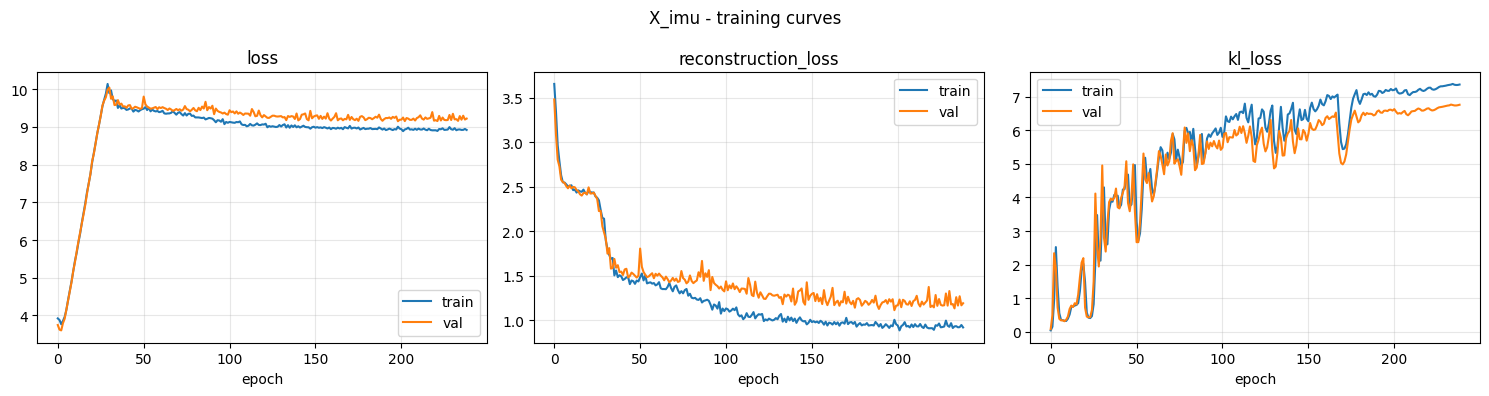

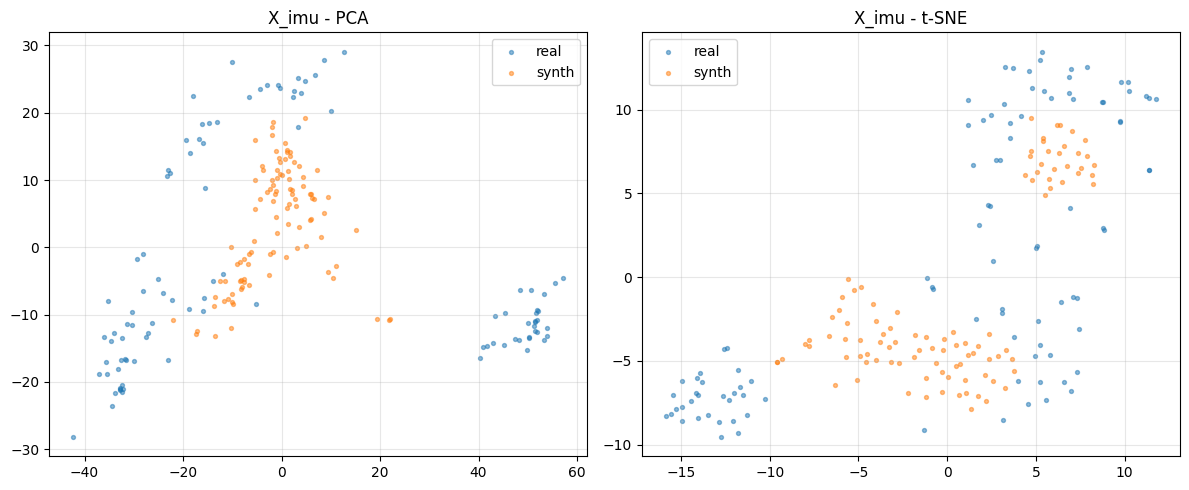

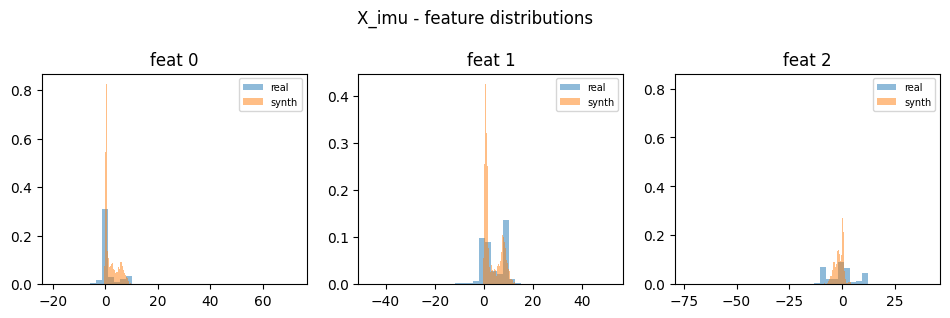

    saved -> c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_generated_improved\X_imu

EXPERIMENT 2/4: X_imu_ir  (own Prep / VAE / optimizer)
    split train=79 val=20 | T=32 F_full=771 -> modeled K=32 (dropped 0 const, pca=True)
    [warn] KL=0.0193 very low -> possible posterior collapse (lower beta / raise free_bits).
    trained 228 epochs in 14.8s | best val_recon=14.7311 | final KL=7.289
    generated 99 synthetic samples, shape=(99, 32, 771)
    [warn] X_imu_ir: low diversity (possible mode collapse)


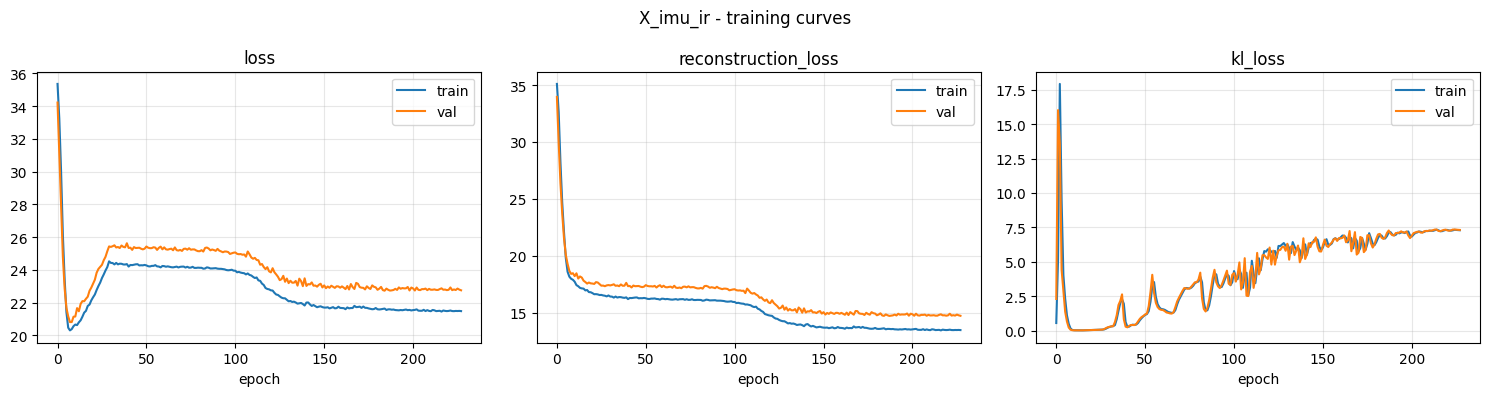

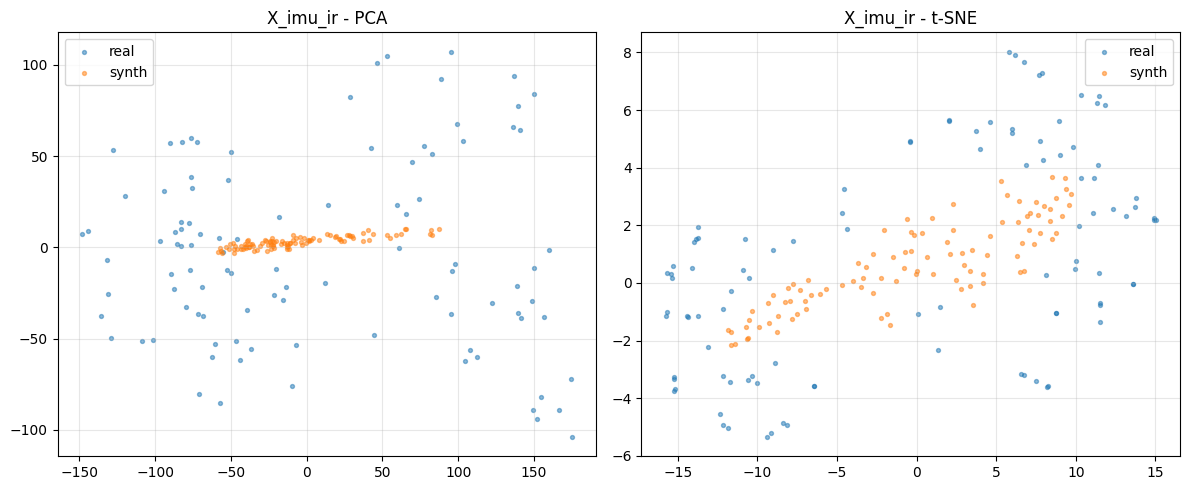

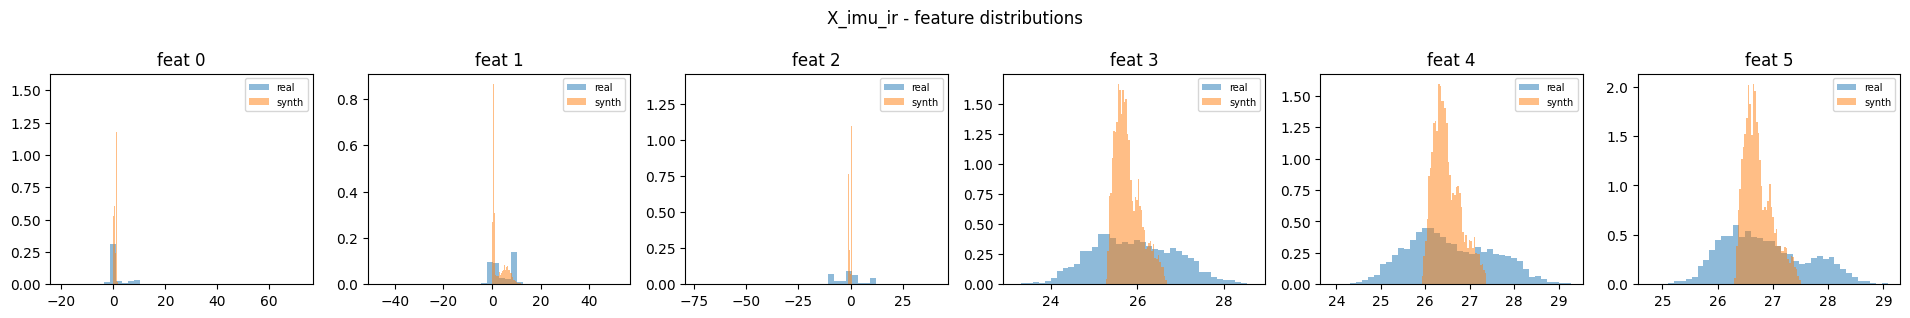

    saved -> c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_generated_improved\X_imu_ir

EXPERIMENT 3/4: X_imu_radar  (own Prep / VAE / optimizer)
    split train=79 val=20 | T=32 F_full=1137 -> modeled K=32 (dropped 294 const, pca=True)
    trained 139 epochs in 10.0s | best val_recon=24.5603 | final KL=7.619
    generated 99 synthetic samples, shape=(99, 32, 1137)


c:\Users\mabideen\AppData\Local\miniforge3\envs\exp2_env\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\mabideen\AppData\Local\miniforge3\envs\exp2_env\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


    [warn] X_imu_radar: low diversity (possible mode collapse)


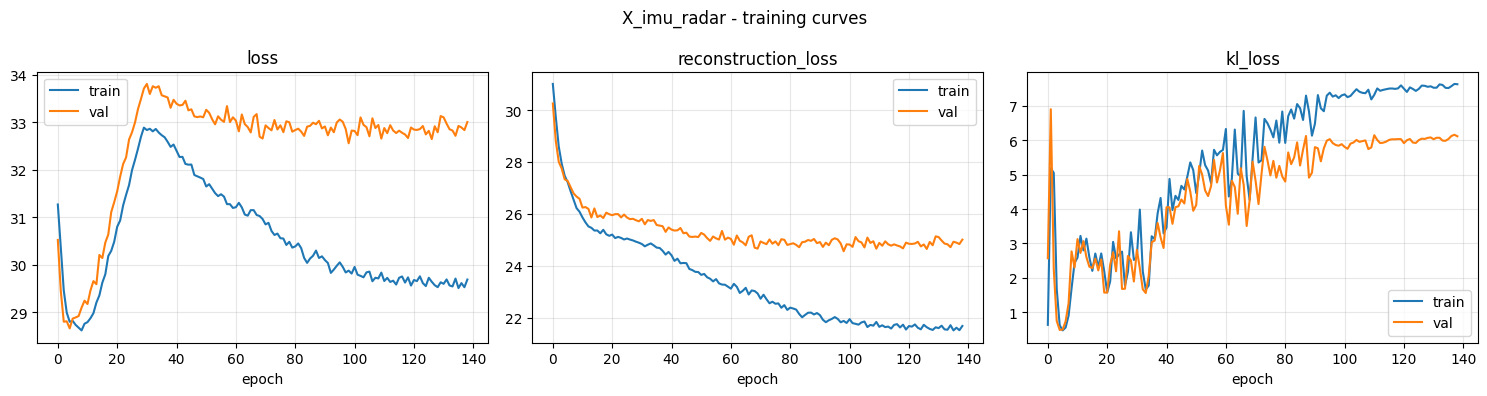

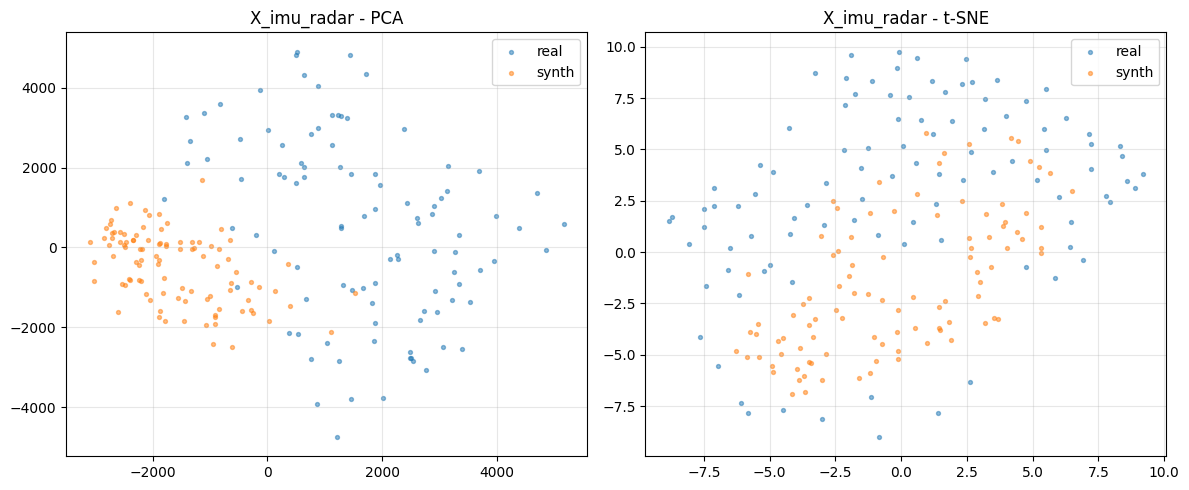

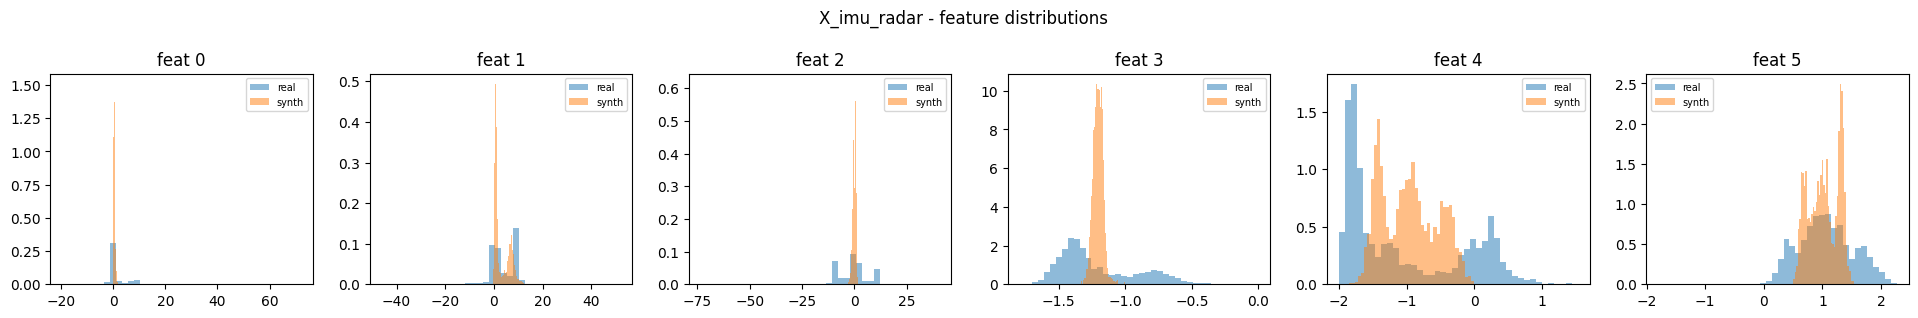

    saved -> c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_generated_improved\X_imu_radar

EXPERIMENT 4/4: X_imu_ir_radar  (own Prep / VAE / optimizer)
    split train=79 val=20 | T=32 F_full=1905 -> modeled K=32 (dropped 294 const, pca=True)
    trained 139 epochs in 9.9s | best val_recon=24.4154 | final KL=7.362
    generated 99 synthetic samples, shape=(99, 32, 1905)


c:\Users\mabideen\AppData\Local\miniforge3\envs\exp2_env\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\mabideen\AppData\Local\miniforge3\envs\exp2_env\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


    [warn] X_imu_ir_radar: low diversity (possible mode collapse)


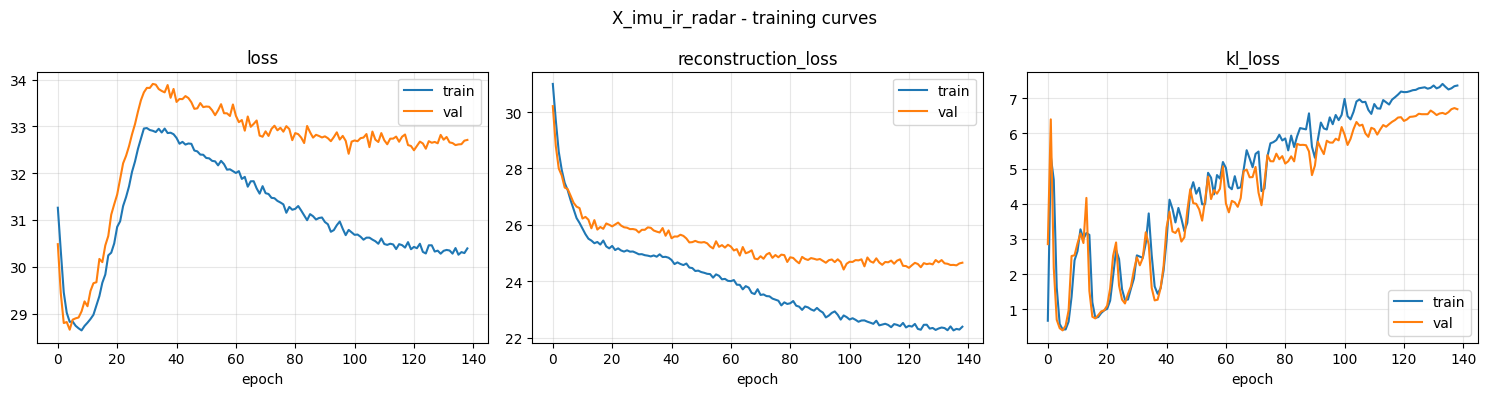

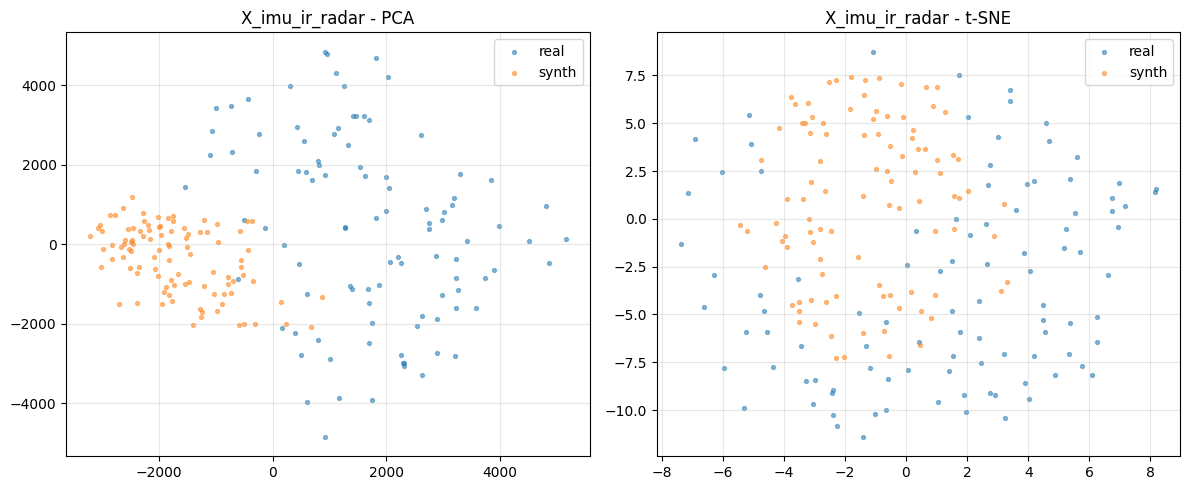

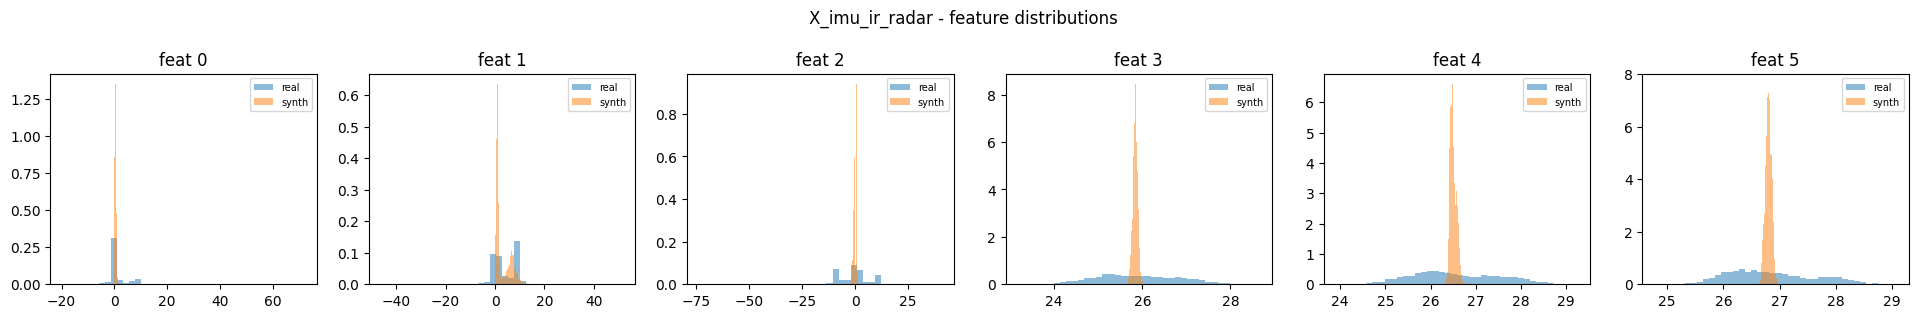

    saved -> c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_generated_improved\X_imu_ir_radar

CROSS-DATASET SUMMARY (improved, independent experiments)


,n_real,n_synth,modeled_dim,final_kl_loss,mmd,wasserstein,corr_difference,ocsvm_real_inlier,ocsvm_synth_inlier,score_gap,variance_increase,diversity_ratio
dataset,,,,,,,,,,,,
X_imu,99,99,3,7.36861,0.21178,2.52318,0.34380,0.85859,0.76768,0.09909,-0.35470,0.23009
X_imu_ir,99,99,32,7.28947,0.19511,0.46550,0.34535,0.82828,1.00000,0.72246,-0.43181,0.21473
X_imu_radar,99,99,32,7.61908,0.31349,6.26910,0.32330,0.82828,1.00000,0.31592,-0.41860,0.33019
X_imu_ir_radar,99,99,32,7.36234,0.33530,4.09395,0.38123,0.81818,1.00000,0.52235,-0.45194,0.29525


In [41]:
SEP = "=" * 50

def run_experiment(idx, total, name, X, cfg: Config):
    print(f"\n{SEP}\nEXPERIMENT {idx}/{total}: {name}  (own Prep / VAE / optimizer)\n{SEP}")
    assert isinstance(X, np.ndarray) and X.ndim == 3, "each experiment trains on ONE dataset only"
    set_seeds(cfg.seed)
    out_dir = cfg.output_dir / name; out_dir.mkdir(parents=True, exist_ok=True)

    X_tr, X_val = split_data(X, cfg)
    prep = Prep(cfg).fit(X_tr)
    Xtr_s, Xval_s = prep.transform(X_tr), prep.transform(X_val)
    T, K = prep.T, prep.K
    print(f"    split train={len(X_tr)} val={len(X_val)} | T={T} F_full={prep.F_full} "
          f"-> modeled K={K} (dropped {prep.n_dropped} const, pca={prep.pca is not None})")

    vae = build_vae(T, K, cfg)
    hist = train_vae(vae, Xtr_s, Xval_s, cfg, out_dir / "best.weights.h5")

    latent_stats = fit_latent_prior(vae, Xtr_s) if cfg.sample_from_posterior else None
    n_synth = int(cfg.n_synthetic) if cfg.n_synthetic else int(round(cfg.synthetic_ratio * len(X)))
    synthetic, synth_scaled = generate_samples(vae, prep, n_synth, cfg, latent_stats)
    print(f"    generated {len(synthetic)} synthetic samples, shape={synthetic.shape}")

    metrics = evaluate(X, synthetic, hist, cfg)
    warns = health_report(name, synth_scaled, metrics, cfg)
    make_plots(name, X, synthetic, hist, out_dir, cfg)

    meta = {"dataset": name, "n_real": len(X), "n_synth": len(synthetic), "seq_len": T,
            "n_features": prep.F_full, "modeled_dim": K, "n_const_dropped": prep.n_dropped,
            "used_pca": prep.pca is not None, "latent_dim": cfg.latent_dim, "beta": cfg.beta,
            "free_bits": cfg.free_bits, "epochs_run": len(hist.history["loss"]), **metrics}
    save_outputs(name, out_dir, synthetic, prep, vae, metrics, meta, warns)
    print(f"    saved -> {out_dir}")
    return meta

def run_all(cfg: Config):
    rows, failures = [], {}
    items = list(RAW.items())
    for i, (name, X) in enumerate(items, 1):
        try:
            rows.append(run_experiment(i, len(items), name, X, cfg))
        except Exception as e:
            failures[name] = repr(e); print(f"    [ERROR] {name} failed: {e!r}")
    summary = pd.DataFrame(rows).set_index("dataset") if rows else pd.DataFrame()
    if not summary.empty: summary.to_csv(cfg.output_dir / "summary.csv")
    if failures: print("\nFailures:", failures)
    return summary

SUMMARY = run_all(CFG)
print("\n" + "=" * 50 + "\nCROSS-DATASET SUMMARY (improved, independent experiments)\n" + "=" * 50)
cols = ["n_real","n_synth","modeled_dim","final_kl_loss","mmd","wasserstein","corr_difference",
        "ocsvm_real_inlier","ocsvm_synth_inlier","score_gap","variance_increase","diversity_ratio"]
display(SUMMARY[[c for c in cols if c in SUMMARY.columns]] if not SUMMARY.empty else SUMMARY)


## Download the four synthetic datasets

In [43]:
import shutil
if CFG.output_dir.exists():
    archive = shutil.make_archive(str(CFG.output_dir), "zip", root_dir=str(CFG.output_dir))
    print("Zipped ->", archive)
    print("\nSynthetic datasets produced:")
    for sub in sorted(CFG.output_dir.iterdir()):
        syn = sub / "synthetic.npy"
        if syn.exists():
            print(f"  {sub.name:16s} {syn}  shape={np.load(syn).shape}")


## Comparing against the baseline

`diversity_ratio` should now sit closer to 1.0, `final_kl_loss` should be healthy (no posterior collapse),
and `mmd` should drop on the wide sets thanks to the log/PCA preprocessing. Note `corr_frob_norm` here is
already normalised by feature count, so it is comparable across datasets (unlike the baseline's raw
`corr_frobenius`). To compare fairly, line up this run's `vae_generated_improved/summary.csv` against the
baseline `vae_generated/summary.csv`.